In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from AGNoptspecNN.model.preprocess import *
from AGNoptspecNN.model.classifier import *
from sklearn.metrics import classification_report

2025-08-09 21:14:20.036514: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-09 21:14:20.045898: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-09 21:14:20.121994: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-09 21:14:20.189474: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754754260.252759  158780 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754754260.27

**X1**:  500 Interpolated points \
**X2**: 1000 Interpolated points \
**X3**: 2000 Interpolated points 

**Y** : Corresponding labels same for each.

In [2]:
SPECTRA_DIR = "/home/tathagata/Documents/coding/AGNspecCNN/simulated_spectra/"

X1, X2, X3, Y = testing_files(nfiles=3000, SPECTRA_DIR=SPECTRA_DIR)

In [3]:
y, ypred = tests(X1, X2, X3, Y)

cm = tf.math.confusion_matrix(labels=y, predictions=ypred)

print("===== Metrics of the test-data =====")
print(classification_report(y, ypred))

2025-08-09 16:43:03.620916: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
===== Metrics of the test-data =====
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00      1000
         1.0       1.00      0.99      1.00      1000
         2.0       0.99      1.00      1.00      1000

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



#### The combined confusion matrix:
- For each spectrum interpolated at 500, 1000, 2000 points.
- This gives better performance.


Text(45.722222222222214, 0.5, 'Truth')

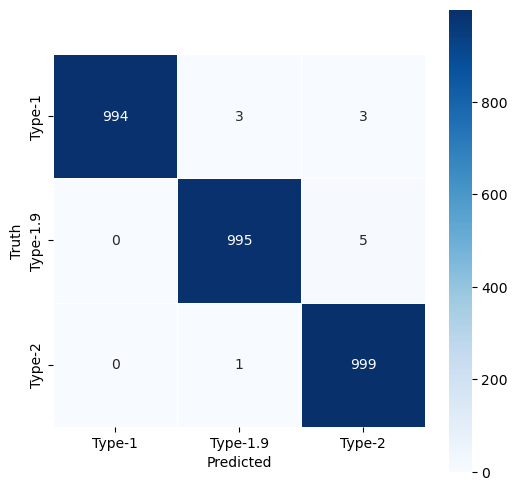

In [4]:
labels = ['Type-1', 'Type-1.9', 'Type-2']

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', linewidths=.5, square = True, cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Truth')

#### Individual Real Spectral Classification 

In [5]:
Spectrum_1 = np.loadtxt("/home/tathagata/Documents/coding/AGNspecCNN/rough_testing_field/20200123_keck_1.spec", usecols=(0,1))
Spectrum_2 = np.loadtxt("/home/tathagata/Documents/coding/AGNspecCNN/rough_testing_field/20200226_dct.spec", usecols=(0,1))
Spectrum_3 = np.loadtxt("/home/tathagata/Documents/coding/AGNspecCNN/rough_testing_field/20210911_saao.spec", usecols=(0,1))

Text(0, 0.5, 'flux [erg s$^{-1}$ cm$^{-2}$ $\\AA^{-1}$]')

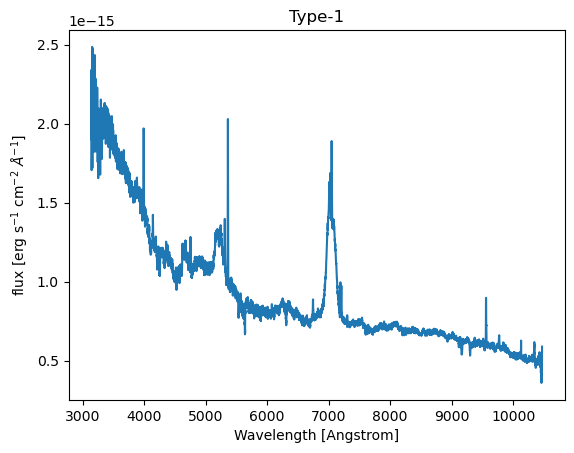

In [6]:
plt.title("Type-1")
plt.plot(Spectrum_1[:,0], Spectrum_1[:,1])
plt.xlabel("Wavelength [Angstrom]")
plt.ylabel(r"flux [erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$]")

Text(0, 0.5, 'flux [erg s$^{-1}$ cm$^{-2}$ $\\AA^{-1}$]')

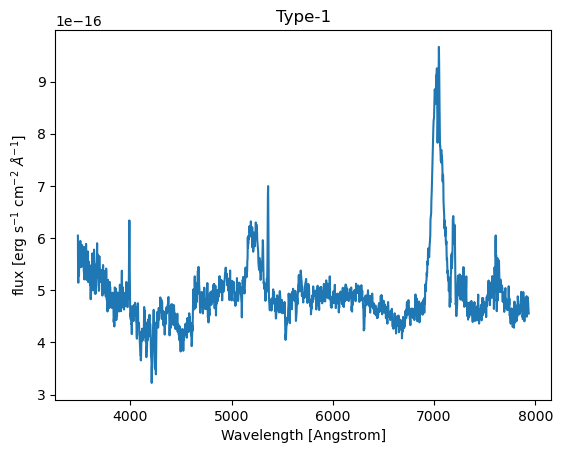

In [7]:
plt.title("Type-1")
plt.plot(Spectrum_2[:,0], Spectrum_2[:,1])
plt.xlabel("Wavelength [Angstrom]")
plt.ylabel(r"flux [erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$]")

Text(0, 0.5, 'flux [erg s$^{-1}$ cm$^{-2}$ $\\AA^{-1}$]')

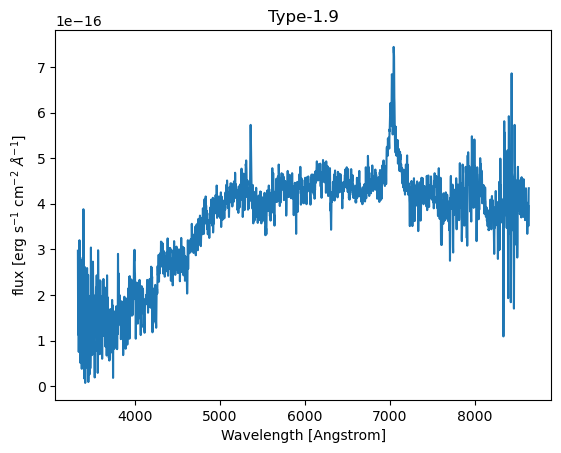

In [8]:
plt.title("Type-1.9")
plt.plot(Spectrum_3[:,0], Spectrum_3[:,1])
plt.xlabel("Wavelength [Angstrom]")
plt.ylabel(r"flux [erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$]")

===== Message from classifier =====
Network output 0: thus Type 1 AGN.


Text(0.5, 1.0, 'Output from each model')

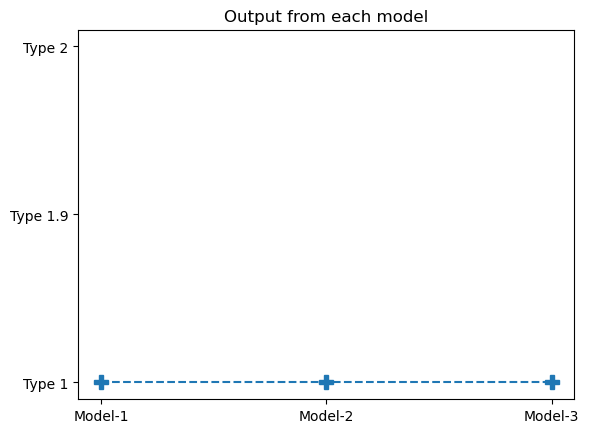

In [12]:
A = ClassificationModel()

type_no = np.array([0,1,2])
type_labels = np.array(["Type 1", "Type 1.9", "Type 2"], dtype="str")

ypred, prediction_model, model_label, y_prediction_list = A.classify_the_spectrum(Spectrum_1) # J0428-00 -- KECK

plt.plot(prediction_model, y_prediction_list, "--P", markersize=10)
plt.xticks(prediction_model, model_label)
plt.yticks(type_no, type_labels)
plt.ylim(-0.1,2.1)
plt.title("Output from each model")

===== Message from classifier =====
Network output 0: thus Type 1 AGN.


Text(0.5, 1.0, 'Output from each model')

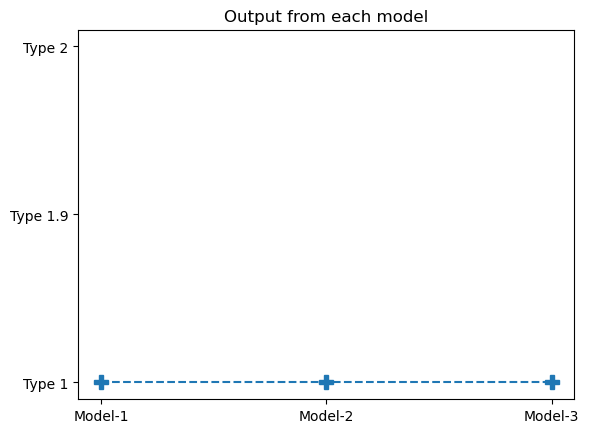

In [15]:
ypred, prediction_model, model_label, y_prediction_list = A.classify_the_spectrum(Spectrum_2) # J0428-00 -- KECK

plt.plot(prediction_model, y_prediction_list, "--P", markersize=10)
plt.xticks(prediction_model, model_label)
plt.yticks(type_no, type_labels)
plt.ylim(-0.1,2.1)
plt.title("Output from each model")



===== Message from classifier =====
Network output 1: thus Type 1.9 AGN.


Text(0.5, 1.0, 'Output from each model')

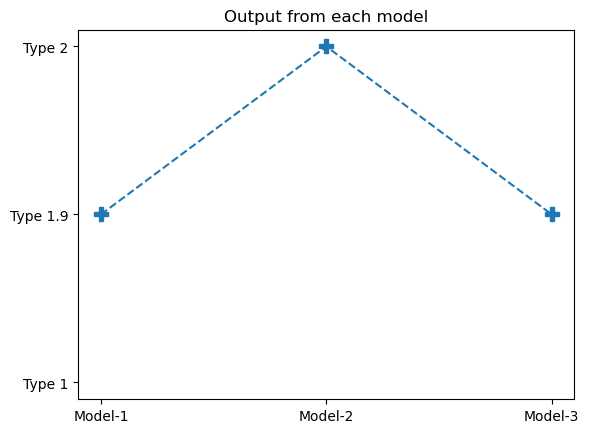

In [16]:
ypred, prediction_model, model_label, y_prediction_list = A.classify_the_spectrum(Spectrum_3) # J0428-00 -- KECK

plt.plot(prediction_model, y_prediction_list, "--P", markersize=10)
plt.xticks(prediction_model, model_label)
plt.yticks(type_no, type_labels)
plt.ylim(-0.1,2.1)
plt.title("Output from each model")
